# AI Feature Unit Economics

Companion notebook for [`5_unit_economics_and_pricing.md`](../5_unit_economics_and_pricing.md).

There is no model in this notebook. It is arithmetic — on purpose.

The hardest number in production AI is not a gradient. It is the second decimal place of your cost per user, and almost everybody gets it wrong by 3–10× the first time.

**How to use this:** at each step there is a *predict* prompt. Write your guess down before you run the cell. The gap between your guess and the output is the entire lesson.

Feature we are costing: **a support-thread summariser.** A user opens a support ticket thread and gets a short summary.

---

## Setup

Illustrative 2026 price tiers, in dollars per 1M tokens. Check real provider pricing before you quote these to anyone — the *shape* is what matters here, not the exact cents.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# $ per 1,000,000 tokens
PRICES = {
    #  tier        input   output   cached_input (~90% off input)
    "frontier": {"in": 3.00, "out": 15.00, "cached_in": 0.30},
    "mid":      {"in": 0.80, "out":  4.00, "cached_in": 0.08},
    "small":    {"in": 0.10, "out":  0.40, "cached_in": 0.01},
}

def cost(in_tokens=0, out_tokens=0, cached_in_tokens=0, tier="frontier"):
    "Dollar cost of one model call."
    p = PRICES[tier]
    return (in_tokens        * p["in"]
          + cached_in_tokens * p["cached_in"]
          + out_tokens       * p["out"]) / 1_000_000

pd.DataFrame(PRICES).T

,in,out,cached_in
frontier,3.0000,15.0000,0.3000
mid,0.8000,4.0000,0.0800
small,0.1000,0.4000,0.0100


---

## Step 1 — What one task costs

One summary:

- **3,000 input tokens** — the thread, plus the system prompt, plus 2 few-shot examples
- **250 output tokens** — the summary itself

An average user does 40 a month.

In [2]:
IN_TOKENS   = 3_000
OUT_TOKENS  = 250
TASKS_MONTH = 40

per_task = cost(IN_TOKENS, OUT_TOKENS, tier="frontier")
per_user = per_task * TASKS_MONTH

print(f"input  : {IN_TOKENS:>6,} tok x $3.00/M  = ${IN_TOKENS  * 3.00/1e6:.5f}")
print(f"output : {OUT_TOKENS:>6,} tok x $15.00/M = ${OUT_TOKENS * 15.00/1e6:.5f}")
print(f"{'':->46}")
print(f"cost per summary                 = ${per_task:.5f}")
print(f"cost per user per month  (x{TASKS_MONTH})   = ${per_user:.4f}")

input  :  3,000 tok x $3.00/M  = $0.00900
output :    250 tok x $15.00/M = $0.00375
----------------------------------------------
cost per summary                 = $0.01275
cost per user per month  (x40)   = $0.5100


$0.51 per user per month. Looks harmless.

Two things are about to go wrong with it.

---

## Step 2 — The conversation growth trap

Now a different feature: a **chat assistant**. Each turn the user writes ~300 tokens and the model replies with ~400. There is a 200-token system prompt. A real conversation runs 20 turns.

### ✋ Predict first

> **How many input tokens does the whole 20-turn conversation cost?**

Write your number down. Then run the cell.

In [3]:
SYSTEM      = 200
USER_TURN   = 300
ASSIST_TURN = 400
TURNS       = 20

# The model has no memory. Every turn resends the whole history.
rows = []
history = 0                      # tokens of past turns carried forward
for n in range(1, TURNS + 1):
    turn_in  = SYSTEM + history + USER_TURN
    turn_out = ASSIST_TURN
    rows.append({"turn": n, "input_tokens": turn_in, "output_tokens": turn_out})
    history += USER_TURN + ASSIST_TURN

conv = pd.DataFrame(rows)
total_in  = conv.input_tokens.sum()
total_out = conv.output_tokens.sum()

naive_in  = (SYSTEM + USER_TURN) * TURNS       # what most people estimate

print(conv.head(3).to_string(index=False))
print("...")
print(conv.tail(2).to_string(index=False))
print()
print(f"naive estimate of input tokens : {naive_in:>9,}")
print(f"ACTUAL input tokens            : {total_in:>9,}   <- {total_in/naive_in:.1f}x")
print(f"output tokens                  : {total_out:>9,}")

 turn  input_tokens  output_tokens
    1           500            400
    2          1200            400
    3          1900            400
...
 turn  input_tokens  output_tokens
   19         13100            400
   20         13800            400

naive estimate of input tokens :    10,000
ACTUAL input tokens            :   143,000   <- 14.3x
output tokens                  :     8,000


In [4]:
naive_cost  = cost(naive_in, total_out, tier="frontier")
actual_cost = cost(total_in,  total_out, tier="frontier")

print(f"naive cost per conversation  : ${naive_cost:.4f}")
print(f"ACTUAL cost per conversation : ${actual_cost:.4f}")
print(f"you were wrong by            :  {actual_cost/naive_cost:.1f}x")

naive cost per conversation  : $0.1500
ACTUAL cost per conversation : $0.5490
you were wrong by            :  3.7x


Input grows with the **square** of the turn count, not linearly. Here is the shape — and why a 3-turn demo tells you nothing about a 20-turn conversation.

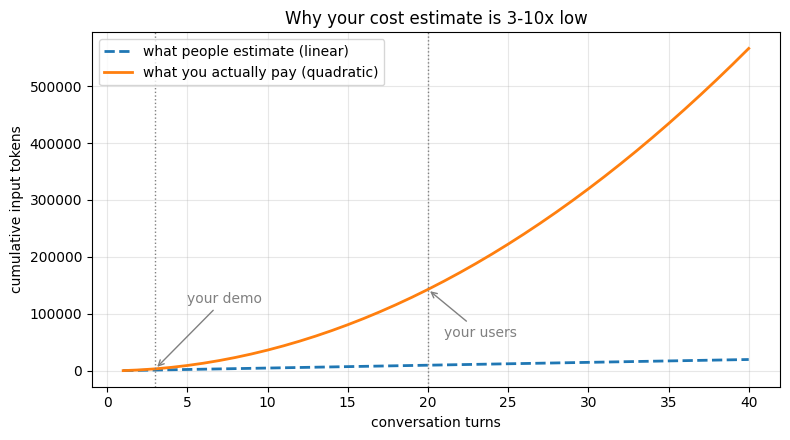

In [5]:
turns = np.arange(1, 41)
cum_actual = np.cumsum(SYSTEM + USER_TURN + (turns - 1) * (USER_TURN + ASSIST_TURN))
cum_naive  = (SYSTEM + USER_TURN) * turns

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(turns, cum_naive,  label="what people estimate (linear)", lw=2, ls="--")
ax.plot(turns, cum_actual, label="what you actually pay (quadratic)", lw=2)
ax.axvline(3,  color="gray", lw=1, ls=":")
ax.axvline(20, color="gray", lw=1, ls=":")
ax.annotate("your demo", xy=(3, cum_actual[2]), xytext=(5, 120_000),
            arrowprops=dict(arrowstyle="->", color="gray"), color="gray")
ax.annotate("your users", xy=(20, cum_actual[19]), xytext=(21, 60_000),
            arrowprops=dict(arrowstyle="->", color="gray"), color="gray")
ax.set_xlabel("conversation turns")
ax.set_ylabel("cumulative input tokens")
ax.set_title("Why your cost estimate is 3-10x low")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 3 — Prompt caching, the biggest lever

Both Anthropic and OpenAI charge roughly **90% less** for *cached* input tokens.

In a conversation, almost the entire prompt is a repeat of last turn's prompt. Only the newest user message (and the previous assistant reply) is new.

### ✋ Predict first

> **What percentage of the $0.55 conversation does caching remove?**

In [6]:
# New (uncached) tokens per turn: turn 1 sends everything new;
# every later turn adds only the previous assistant reply + the new user message.
new_tokens    = (SYSTEM + USER_TURN) + (TURNS - 1) * (ASSIST_TURN + USER_TURN)
cached_tokens = total_in - new_tokens

cached_cost = cost(in_tokens=new_tokens,
                   cached_in_tokens=cached_tokens,
                   out_tokens=total_out,
                   tier="frontier")

print(f"new (full price) input tokens : {new_tokens:>9,}")
print(f"cached (90% off) input tokens : {cached_tokens:>9,}")
print()
print(f"uncached cost : ${actual_cost:.4f}")
print(f"cached cost   : ${cached_cost:.4f}")
print(f"saving        :  {(1 - cached_cost/actual_cost)*100:.1f}%   (no quality change)")

new (full price) input tokens :    13,800
cached (90% off) input tokens :   129,200

uncached cost : $0.5490
cached cost   : $0.2002
saving        :  63.5%   (no quality change)


### Break it on purpose

Caching only works if the prompt **prefix is byte-identical** every time. Put a timestamp, a session ID, or a shuffled retrieval order at the top and every cache hit disappears.

This is a real bug people ship. The bill doubles and nothing else looks different.

In [7]:
def conversation_cost(prefix_is_stable=True):
    if prefix_is_stable:
        return cost(new_tokens, total_out, cached_tokens, "frontier")
    # a timestamp at the top invalidates the prefix -> nothing is ever cached
    return cost(total_in, total_out, 0, "frontier")

good = conversation_cost(True)
bad  = conversation_cost(False)

print(f'system prompt: "You are a helpful assistant."               -> ${good:.4f}')
print(f'system prompt: "You are a helpful assistant. Time: 14:07:22" -> ${bad:.4f}')
print()
print(f"one line of code, {bad/good:.1f}x the bill, identical output")

system prompt: "You are a helpful assistant."               -> $0.2002
system prompt: "You are a helpful assistant. Time: 14:07:22" -> $0.5490

one line of code, 2.7x the bill, identical output


---

## Step 4 — Model routing

Send everything to the small model first. Escalate to the frontier model only when the small one can't handle it.

The catch: **the router can be wrong.** A misrouted hard task is a bad answer at a 90% discount, which is not a saving. So we plot cost *and* quality together.

In [8]:
small_task    = cost(IN_TOKENS, OUT_TOKENS, tier="small")
frontier_task = per_task

print(f"small tier    : ${small_task:.5f} per summary")
print(f"frontier tier : ${frontier_task:.5f} per summary")
print(f"ratio         :  {frontier_task/small_task:.0f}x\n")

# quality assumption: small model passes the eval on easy tasks only
SMALL_SCORE_ON_EASY, FRONTIER_SCORE = 0.86, 0.91

rows = []
for easy_share in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]:
    blended_cost  = easy_share * small_task + (1 - easy_share) * frontier_task
    blended_score = easy_share * SMALL_SCORE_ON_EASY + (1 - easy_share) * FRONTIER_SCORE
    rows.append({
        "% routed to small": f"{easy_share:.0%}",
        "cost per task": blended_cost,
        "cost saving": f"{(1 - blended_cost/frontier_task)*100:.0f}%",
        "eval score": f"{blended_score:.1%}",
        "points lost": f"{(FRONTIER_SCORE - blended_score)*100:.1f}",
    })

pd.DataFrame(rows)

small tier    : $0.00040 per summary
frontier tier : $0.01275 per summary
ratio         :  32x



,% routed to small,cost per task,cost saving,eval score,points lost
0,0%,0.0127,0%,91.0%,0.0
1,30%,0.0090,29%,89.5%,1.5
2,50%,0.0066,48%,88.5%,2.5
3,70%,0.0041,68%,87.5%,3.5
4,90%,0.0016,87%,86.5%,4.5
5,100%,0.0004,97%,86.0%,5.0


Read the last two columns together, never the cost column alone.

At a 70/30 split you save **68%** and give up **3.5 points** of task success. Whether that is a good trade is a product decision — but you can only make it if you measured both, which is what the eval set in [`3_evals_as_the_product_spec.md`](../3_evals_as_the_product_spec.md) is for.

---

## Step 5 — The LLM bill is not your COGS

### ✋ Predict first

> **What fraction of total cost per user do you think the model inference is?**

In [9]:
FIXED_PER_USER = {          # does not grow with usage
    "vector DB hosting":        0.35,
    "eval runs (amortised)":    0.04,
}
PER_TASK_EXTRA = {          # grows with every task, on top of the LLM call
    "embeddings + re-indexing": 0.12 / TASKS_MONTH,
    "observability / traces":   0.18 / TASKS_MONTH,
    "human escalations":        0.50 / TASKS_MONTH,   # 2% x 1.5 min x $25/hr
}

def cogs(tasks_per_month, task_cost=per_task):
    fixed    = sum(FIXED_PER_USER.values())
    variable = tasks_per_month * (task_cost + sum(PER_TASK_EXTRA.values()))
    return fixed + variable

lines = {"LLM inference": per_task * TASKS_MONTH}
lines.update({k: v * TASKS_MONTH for k, v in PER_TASK_EXTRA.items()})
lines.update(FIXED_PER_USER)

table = pd.DataFrame({"$/user/month": lines})
table.loc["TOTAL COGS"] = table["$/user/month"].sum()
display(table.style.format("{:.2f}"))

print(f"\nLLM inference is {lines['LLM inference']/table.loc['TOTAL COGS','$/user/month']:.0%} of total COGS.")
print("Optimising it to zero still leaves you paying "
      f"${table.loc['TOTAL COGS','$/user/month'] - lines['LLM inference']:.2f} per user.")

,$/user/month
LLM inference,0.51
embeddings + re-indexing,0.12
observability / traces,0.18
human escalations,0.50
vector DB hosting,0.35
eval runs (amortised),0.04
TOTAL COGS,1.70



LLM inference is 30% of total COGS.
Optimising it to zero still leaves you paying $1.19 per user.


Note the `human escalations` line. Your escalation rate from [`4_designing_for_probabilistic_output.md`](../4_designing_for_probabilistic_output.md) is a **cost line** — halve it and you cut COGS. Design quality shows up directly in gross margin.

---

## Step 6 — Why flat per-seat pricing breaks

Usage is never uniform. Same feature, four cohorts, one $20/seat price.

### ✋ Predict first

> **At $20 a seat, how many summaries per month makes a user unprofitable?**

In [10]:
PRICE = 20.00

cohorts = [("Light  (60% of users)", 8),
           ("Average (35%)",        40),
           ("Heavy   (4%)",        400),
           ("Power   (1%)",      2_000)]

rows = []
for name, t in cohorts:
    c = cogs(t)
    rows.append({"cohort": name, "tasks/mo": t,
                 "LLM cost": per_task * t, "total COGS": c,
                 "profit": PRICE - c, "gross margin": f"{(PRICE - c)/PRICE:.0%}"})

display(pd.DataFrame(rows).set_index("cohort")
        .style.format({"tasks/mo": "{:,.0f}", "LLM cost": "${:.2f}",
                       "total COGS": "${:.2f}", "profit": "${:.2f}"}))

fixed    = sum(FIXED_PER_USER.values())
variable = per_task + sum(PER_TASK_EXTRA.values())
breakeven = (PRICE - fixed) / variable
print(f"\nBreak-even usage: {breakeven:,.0f} summaries per month.")
print(f"Above that, every extra summary loses you ${variable:.4f}.")

,tasks/mo,LLM cost,total COGS,profit,gross margin
cohort,,,,,
Light (60% of users),8,$0.10,$0.65,$19.35,97%
Average (35%),40,$0.51,$1.70,$18.30,92%
Heavy (4%),400,$5.10,$13.49,$6.51,33%
Power (1%),"2,000",$25.50,$65.89,$-45.89,-229%



Break-even usage: 599 summaries per month.
Above that, every extra summary loses you $0.0328.


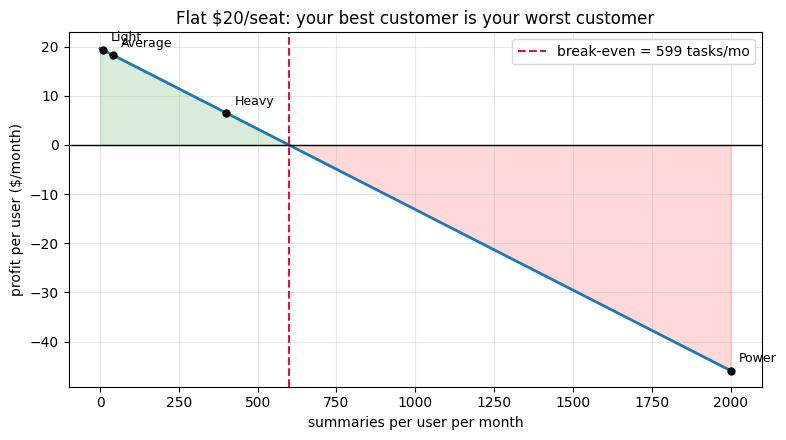

In [11]:
usage = np.arange(0, 2_001, 10)
profit = PRICE - np.array([cogs(t) for t in usage])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(usage, profit, lw=2)
ax.axhline(0, color="black", lw=1)
ax.axvline(breakeven, color="crimson", lw=1.5, ls="--",
           label=f"break-even = {breakeven:,.0f} tasks/mo")
ax.fill_between(usage, profit, 0, where=profit >= 0, alpha=0.15, color="green")
ax.fill_between(usage, profit, 0, where=profit < 0,  alpha=0.15, color="red")
for name, t in cohorts:
    ax.plot(t, PRICE - cogs(t), "o", color="black", ms=5)
    ax.annotate(name.split()[0], (t, PRICE - cogs(t)),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("summaries per user per month")
ax.set_ylabel("profit per user ($/month)")
ax.set_title("Flat $20/seat: your best customer is your worst customer")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Under classic SaaS, heavy usage was pure upside — it meant retention. Under AI economics, unmetered adoption is how you grow into insolvency.

---

## Step 7 — Three pricing shapes

- **Per-seat** — $20/user/month, unlimited. Predictable for the buyer, unbounded risk for you.
- **Pure usage** — $0.05 per summary. Safe margin, but the buyer can't forecast their bill.
- **Hybrid** — $20/month including 100 summaries, then $0.05 each. The 2026 pattern that actually works.

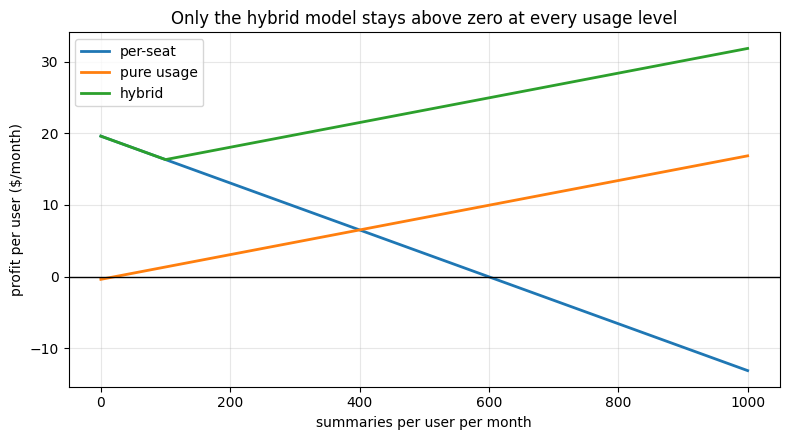

   per-seat | 8 tasks: $  19.35 | 40: $  18.30 | 400: $   6.51 | 2000: $  -45.89
 pure usage | 8 tasks: $  -0.25 | 40: $   0.30 | 400: $   6.51 | 2000: $   34.11
     hybrid | 8 tasks: $  19.35 | 40: $  18.30 | 400: $  21.51 | 2000: $   49.11


In [12]:
OVERAGE, INCLUDED = 0.05, 100

def revenue(model, t):
    if model == "per-seat":    return PRICE
    if model == "pure usage":  return OVERAGE * t
    if model == "hybrid":      return PRICE + OVERAGE * max(0, t - INCLUDED)

usage = np.arange(0, 1_001, 5)
fig, ax = plt.subplots(figsize=(8, 4.5))
for model in ["per-seat", "pure usage", "hybrid"]:
    margin = [(revenue(model, t) - cogs(t)) for t in usage]
    ax.plot(usage, margin, lw=2, label=model)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("summaries per user per month")
ax.set_ylabel("profit per user ($/month)")
ax.set_title("Only the hybrid model stays above zero at every usage level")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for model in ["per-seat", "pure usage", "hybrid"]:
    print(f"{model:>11} | 8 tasks: ${revenue(model,8)-cogs(8):>7.2f} | "
          f"40: ${revenue(model,40)-cogs(40):>7.2f} | "
          f"400: ${revenue(model,400)-cogs(400):>7.2f} | "
          f"2000: ${revenue(model,2000)-cogs(2000):>8.2f}")

Look at the `pure usage` row at 8 tasks: **you lose money on light users**, because your fixed $0.39 never gets covered. That is the failure mode of usage-only pricing, and it is why the hybrid has a floor.

---

## Your turn — modify and debug on purpose

**Predict before every run.** Write the number down first; the gap is the lesson.

1. **Your feature.** Replace `IN_TOKENS`, `OUT_TOKENS` and `TASKS_MONTH` with your own. Guess your cost per user first, to two decimals. How far off were you?

2. **Kill the caching.** Set `TURNS = 5`. Does caching still save 64%? Explain *why* the saving depends on conversation length before you run it.

3. **The retry storm.** Add a `RETRY_RATE = 0.08` — 8% of calls fail and get retried. Where in `cogs()` does it belong, and what does it do to break-even? (Hint: it is not one line.)

4. **Route badly.** In Step 4, change `SMALL_SCORE_ON_EASY` to `0.72`. At what routing split does the cost saving stop being worth the quality loss? There is no right answer — defend yours in three sentences.

5. **Break the COGS model.** Move `vector DB hosting` from `FIXED_PER_USER` into `PER_TASK_EXTRA` at `0.35/TASKS_MONTH`. Break-even changes. Which version is right for a vector DB you rent by the hour, and which for one you rent by the query?

6. **Find the price.** Your CFO wants 70% gross margin on the *Heavy* cohort. Solve for the seat price. Then solve for the included allowance that gets you there at $20 instead. Which is the easier conversation to have with a customer?

7. **Explain it with no AI.** Close this notebook. Say out loud, in under 60 seconds:
   - why a 20-turn conversation costs 3.7× the naive estimate,
   - what one line of code destroys your cache hit rate,
   - and why your best customer loses you money.

   If you stumble on any of the three, re-read [`5_unit_economics_and_pricing.md`](../5_unit_economics_and_pricing.md) — that one is not learned yet.